<a href="https://colab.research.google.com/github/Lorenzo-v8/Vinos-PCA-y-Naive-Bayes/blob/main/Vinos_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Wine.csv to Wine.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap


In [ ]:
df = pd.read_csv('Wine.csv')
df.head()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proli

,0
Class,0
Alcohol,0
Malic acid,0
Ash,0
Alcalinity of ash,0
Magnesium,0
Total phenols,0
Flavanoids,0
Nonflavanoid phenols,0
Proanthocyanins,0


In [ ]:
df['Class'].value_counts()


,count
Class,
2,71
1,59
3,48


In [ ]:
#separo variables y estandarizo
# Separamos features (X) de la clase (y) — Class no entra al PCA
X = df.drop('Class', axis=1)
y = df['Class']

# Estandarizamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

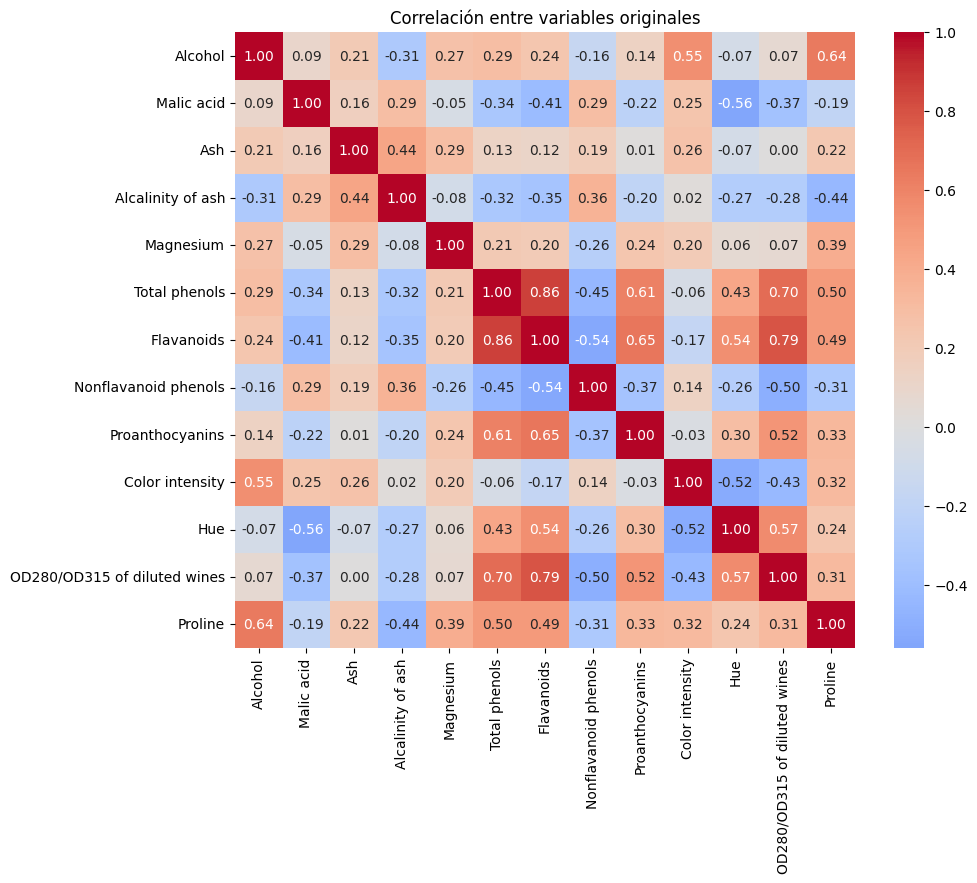

In [ ]:
#matriz de correlacion
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlación entre variables originales')
plt.show()

In [ ]:
X_scaled.mean(axis=0).round(2)  # debería dar ~0 en todas
X_scaled.std(axis=0).round(2)   # debería dar 1 en todas

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada por cada componente
pca.explained_variance_ratio_

array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294,
       0.04935823, 0.04238679, 0.02680749, 0.02222153, 0.01930019,
       0.01736836, 0.01298233, 0.00795215])

In [ ]:
np.cumsum(pca.explained_variance_ratio_).round(3)

array([0.362, 0.554, 0.665, 0.736, 0.802, 0.851, 0.893, 0.92 , 0.942,
       0.962, 0.979, 0.992, 1.   ])

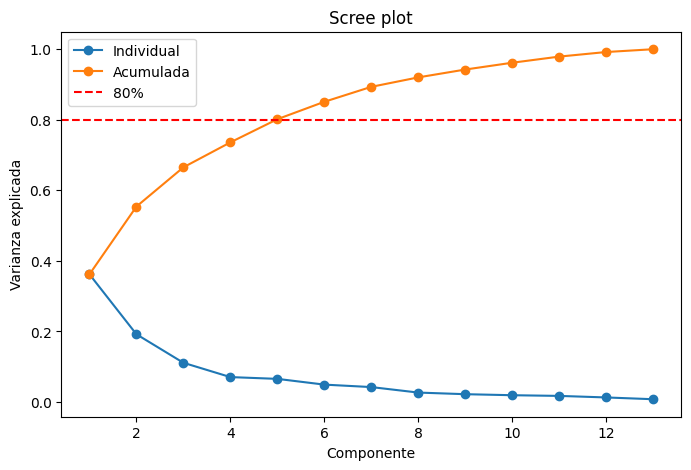

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,14), pca.explained_variance_ratio_, marker='o', label='Individual')
plt.plot(range(1,14), np.cumsum(pca.explained_variance_ratio_), marker='o', label='Acumulada')
plt.axhline(y=0.8, color='r', linestyle='--', label='80%')
plt.xlabel('Componente')
plt.ylabel('Varianza explicada')
plt.legend()
plt.title('Scree plot')
plt.show()

In [ ]:
#PCA final con 2 componentes

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

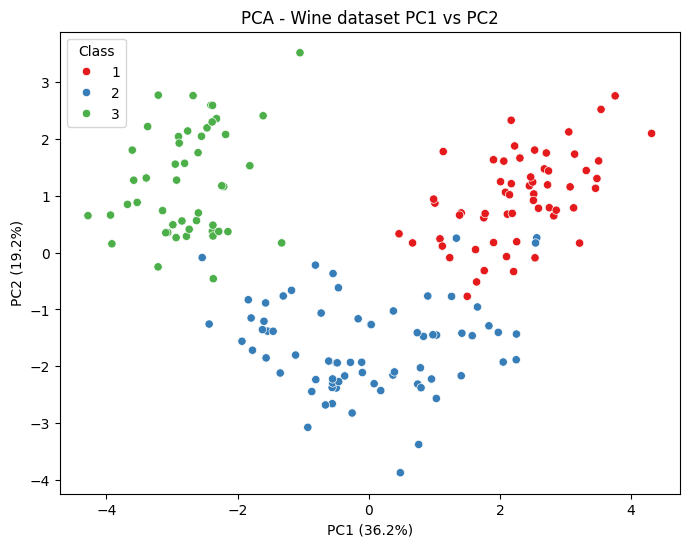

In [ ]:
#Scatter de PC1 vs PC2 coloreado por clase
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=y, palette='Set1')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA - Wine dataset PC1 vs PC2')
plt.legend(title='Class')
plt.show()

In [ ]:
#interpretar los loadings
# ver qué variables originales pesan más en cada componente, para poder explicar qué representa cada eje
loadings = pd.DataFrame(
    pca2.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)
loadings.sort_values('PC1', ascending=False)

,PC1,PC2
Flavanoids,0.422934,-0.003360
Total phenols,0.394661,0.065040
OD280/OD315 of diluted wines,0.376167,-0.164496
Proanthocyanins,0.313429,0.039302
Hue,0.296715,-0.279235
Proline,0.286752,0.364903
Alcohol,0.144329,0.483652
Magnesium,0.141992,0.299634
Ash,-0.002051,0.316069
Color intensity,-0.088617,0.529996


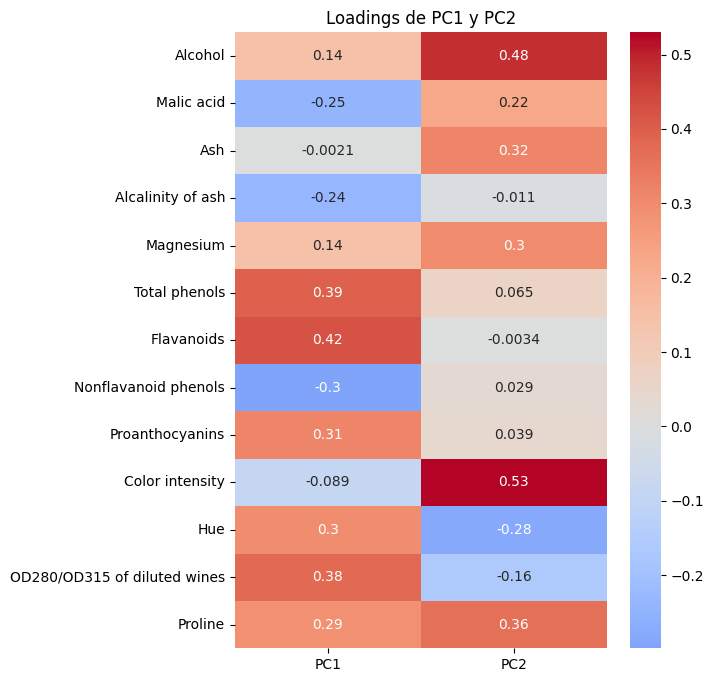

In [ ]:
plt.figure(figsize=(6,8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title('Loadings de PC1 y PC2')
plt.show()

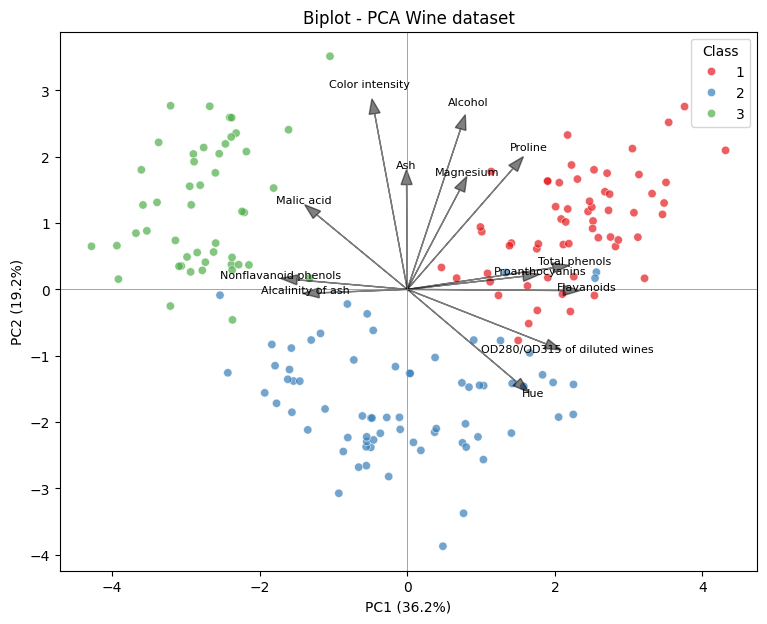

In [ ]:
# Biplot

plt.figure(figsize=(9,7))
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=y, palette='Set1', alpha=0.7)

# Escalamos los loadings para que se vean bien sobre el scatter
scale = 5
for i, var in enumerate(X.columns):
    plt.arrow(0, 0, loadings.iloc[i,0]*scale, loadings.iloc[i,1]*scale,
              color='black', alpha=0.5, head_width=0.15)
    plt.text(loadings.iloc[i,0]*scale*1.15, loadings.iloc[i,1]*scale*1.15,
              var, fontsize=8, ha='center')

plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Biplot - PCA Wine dataset')
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.legend(title='Class')
plt.show()

In [ ]:
# Split común (mismos índices para ambos enfoques)
X_train_full, X_test_full, X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_scaled, X_pca2, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Bayes ingenuo con variables originales estandarizadas
nb_full = GaussianNB()
nb_full.fit(X_train_full, y_train)
y_pred_full = nb_full.predict(X_test_full)

print("=== BAYES INGENUO- variables originales ===")
print("Accuracy:", accuracy_score(y_test, y_pred_full))
print(classification_report(y_test, y_pred_full))
print(confusion_matrix(y_test, y_pred_full))

=== BAYES INGENUO- variables originales ===
Accuracy: 0.9722222222222222
              precision    recall  f1-score   support

           1       0.92      1.00      0.96        12
           2       1.00      0.93      0.96        14
           3       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36

[[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]


In [ ]:
#bayes ingenuo con 2 componentes principales
nb_pca = GaussianNB()
nb_pca.fit(X_train_pca, y_train)
y_pred_pca = nb_pca.predict(X_test_pca)

print("=== BAYES INGENUO - PC1 + PC2 ===")
print("Accuracy:", accuracy_score(y_test, y_pred_pca))
print(classification_report(y_test, y_pred_pca))
print(confusion_matrix(y_test, y_pred_pca))

=== BAYES INGENUO - PC1 + PC2 ===
Accuracy: 0.9166666666666666
              precision    recall  f1-score   support

           1       0.92      0.92      0.92        12
           2       0.87      0.93      0.90        14
           3       1.00      0.90      0.95        10

    accuracy                           0.92        36
   macro avg       0.93      0.92      0.92        36
weighted avg       0.92      0.92      0.92        36

[[11  1  0]
 [ 1 13  0]
 [ 0  1  9]]


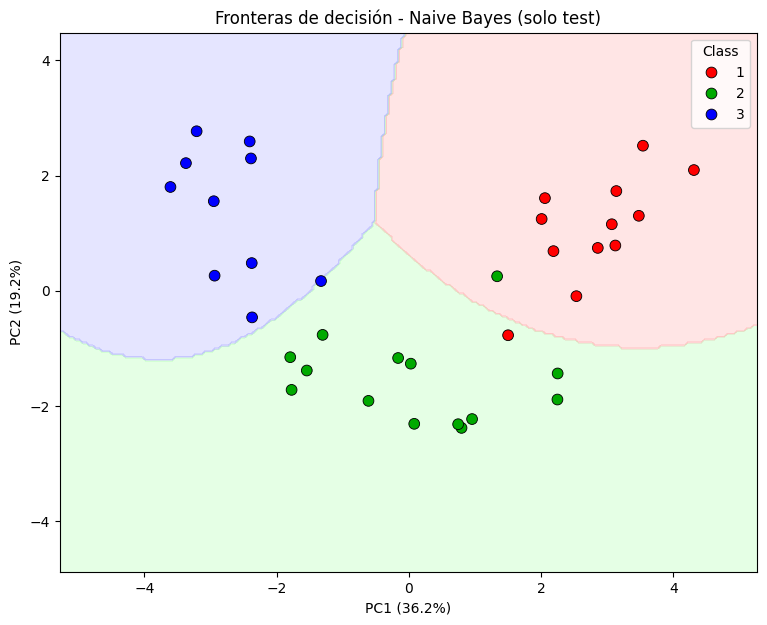

In [ ]:
# puntos cubriendo el rango de PC1 y PC2
x_min, x_max = X_pca2[:, 0].min() - 1, X_pca2[:, 0].max() + 1
y_min, y_max = X_pca2[:, 1].min() - 1, X_pca2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                      np.arange(y_min, y_max, 0.05))

# Predicción del modelo sobre cada punto de la grilla
Z = nb_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Colores para las 3 clases
cmap_background = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_points = ListedColormap(['#FF0000', '#00AA00', '#0000FF'])

plt.figure(figsize=(9,7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_background)

sns.scatterplot(x=X_test_pca[:,0], y=X_test_pca[:,1], hue=y_test,
                 palette=['#FF0000','#00AA00','#0000FF'],
                 edgecolor='black', s=60)

plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Fronteras de decisión - Naive Bayes (solo test)')
plt.legend(title='Class')
plt.show()